#Explanatory Analysis — Fair Price Finder
**Dataset:** `dataset_finalmodel.csv`  
**Tim:** CC26-PSU164

#Pertanyaan Bisnis

1. Berapa rentang harga wajar untuk tiap kategori layanan freelance, dan skill apa yang paling mendorong harga tinggi dalam kategori tersebut?
2. Apakah platform mempengaruhi harga secara signifikan untuk layanan yang sama?
3. Skill apa yang paling berpengaruh terhadap harga tinggi — dan apakah skill teknis lebih menguntungkan dibanding skill digital marketing?
4. Apakah freelancer yang sudah memiliki rating cenderung memasang harga berbeda, dan seberapa besar pengaruh premium skill terhadap harga mereka?
5.  Berapa durasi pengerjaan yang umum untuk tiap kategori, apakah berkorelasi dengan harga, dan segmen durasi mana yang paling banyak diminati pasar?

In [38]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Statistik
import scipy
from scipy.stats import kruskal, mannwhitneyu, spearmanr

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [39]:
df = pd.read_csv('dataset_v2_finalmodel.csv')
print(f"   Jumlah baris  : {df.shape[0]:,}")
print(f"   Jumlah kolom  : {df.shape[1]:,}")
print(df)

   Jumlah baris  : 4,551
   Jumlah kolom  : 66
      price_single  durasi_hari  rating_imputed  has_rating  \
0     3,000,000.00         6.00            4.90           1   
1     2,500,000.00         3.00            4.90           1   
2     1,400,000.00         5.00            4.90           1   
3     1,500,000.00         2.00            4.80           1   
4     2,000,000.00         7.00            5.00           1   
...            ...          ...             ...         ...   
4546  4,000,000.00        14.00            5.00           0   
4547    100,000.00         7.00            5.00           0   
4548    449,000.00        14.00            5.00           0   
4549    150,000.00         7.00            5.00           0   
4550    250,000.00        10.00            4.90           0   

      has_premium_skill  price_range_width  has_price_range  title_length  \
0                     1               0.00                0            84   
1                     0               0.00

#Q1 = Berapa rentang harga wajar untuk tiap kategori layanan freelance, dan skill apa yang paling mendorong harga tinggi dalam kategori tersebut?

-- Rentang Harga per Kategori Layanan --

                           n  Min (Rp)    Q1 (Rp)  Median (Rp)      Q3 (Rp)     Max (Rp)  Mean (Rp)
Kategori                                                                                           
Grafis & Desain          885 50,000.00 100,000.00   150,000.00   300,000.00 5,000,000.00 299,413.63
Pemasaran & Periklanan  1059 50,000.00 300,000.00   500,000.00   750,000.00 6,500,000.00 784,738.57
Penulisan & Terjemahan   720 50,000.00  99,000.00   150,000.00   200,000.00 2,500,000.00 161,535.88
Visual & Audio           546 80,000.00 250,000.00   250,000.00   350,000.00 6,500,000.00 377,522.91
Web & Pemrograman       1341 50,000.00 250,000.00   500,000.00 1,400,000.00 6,500,000.00 908,719.45


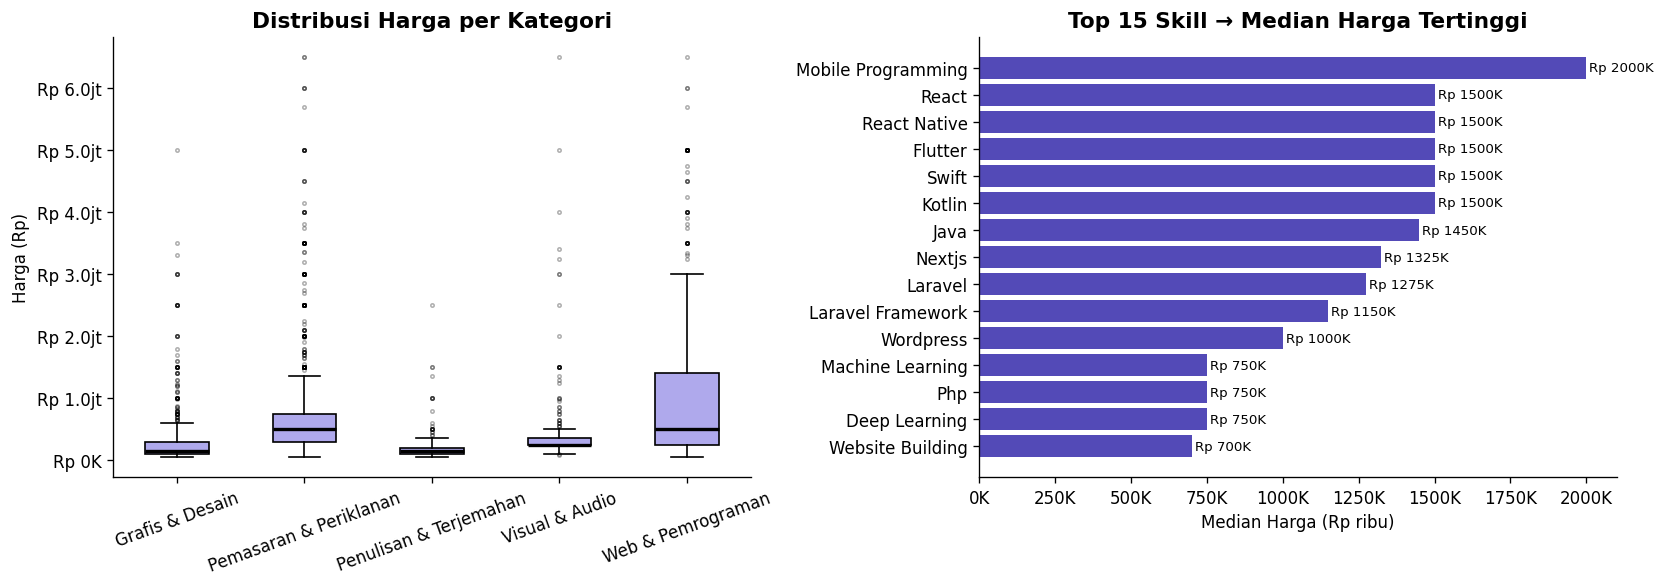


 Top 3 Skill Paling Umum per Kategori

  Grafis & Desain              | Median Rp    150,000 | Logo Design (286), Branding (54), Canva (35)
  Pemasaran & Periklanan       | Median Rp    500,000 | Seo (227), Tiktok Ads (100), Instagram (82)
  Penulisan & Terjemahan       | Median Rp    150,000 | Translation (180), Content Writing (113), Seo (44)
  Visual & Audio               | Median Rp    250,000 | Video Editing (180), Animation (103), Tiktok Ads (98)
  Web & Pemrograman            | Median Rp    500,000 | Ui Ux Design (167), Machine Learning (86), Data Analysis (73)


In [33]:
cat_map = {
    'Grafis & Desain'        : 'kategori_Grafis & Desain',
    'Pemasaran & Periklanan' : 'kategori_Pemasaran & Periklanan',
    'Penulisan & Terjemahan' : 'kategori_Penulisan & Penerjemahan',
    'Visual & Audio'         : 'kategori_Visual & Audio',
    'Web & Pemrograman'      : 'kategori_Web dan Pemrograman',
}
skill_cols = [c for c in df.columns if c.startswith('skill_')]

# --- Tabel ringkasan rentang harga per kategori ---
summary_rows = []
for nama, col in cat_map.items():
    sub = df[df[col] == 1]['price_single']
    summary_rows.append({
        'Kategori'  : nama,
        'n'         : len(sub),
        'Min (Rp)'  : sub.min(),
        'Q1 (Rp)'   : sub.quantile(0.25),
        'Median (Rp)': sub.median(),
        'Q3 (Rp)'   : sub.quantile(0.75),
        'Max (Rp)'  : sub.max(),
        'Mean (Rp)' : sub.mean(),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Kategori')
print("-- Rentang Harga per Kategori Layanan --\n")
print(summary_df.to_string())

# --- Plot 1: Boxplot harga per kategori ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = []
plot_labels = []
for nama, col in cat_map.items():
    plot_data.append(df[df[col] == 1]['price_single'].values)
    plot_labels.append(nama)

axes[0].boxplot(plot_data, labels=plot_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                boxprops=dict(facecolor='#AFA9EC'),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title('Distribusi Harga per Kategori', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Harga (Rp)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=20)

# --- Plot 2: Top 5 skill per median harga ---
skill_price = (
    df[skill_cols].multiply(df['price_single'], axis=0)
    .replace(0, np.nan)
    .median()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)
skill_labels_clean = [s.replace('skill_', '').replace('_', ' ').title() for s in skill_price.index]

colors = ['#534AB7' if df[s].sum() <= 100 else '#1D9E75' for s in skill_price.index]
bars = axes[1].barh(skill_labels_clean[::-1], skill_price.values[::-1] / 1e3, color=colors[::-1])
axes[1].set_title('Top 15 Skill → Median Harga Tertinggi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Harga (Rp ribu)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
for bar, val in zip(bars, skill_price.values[::-1]):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'Rp {val/1e3:.0f}K', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# --- Top 3 skill per kategori ---
print("\n Top 3 Skill Paling Umum per Kategori\n")
for nama, col in cat_map.items():
    sub = df[df[col] == 1]
    top3 = sub[skill_cols].sum().sort_values(ascending=False).head(3)
    skills_str = ', '.join([f"{s.replace('skill_','').replace('_',' ').title()} ({int(v)})" for s, v in top3.items()])
    median_harga = sub['price_single'].median()
    print(f"  {nama:<28} | Median Rp {median_harga:>10,.0f} | {skills_str}")

**Insight:** Kategori Web & Pemrograman memiliki rentang harga paling lebar (Rp 50K–6,5jt) dengan skill mobile dev (Flutter, React, Kotlin) mendorong harga tertinggi hingga Rp 1,5–2jt  menunjukkan variasi kualitas freelancer yang tinggi dan cocok dijadikan segmen utama clustering karena diferensiasi harganya paling signifikan dibanding kategori lain.

#Q2 = Apakah platform mempengaruhi harga secara signifikan untuk layanan yang sama?

Pengaruh Platform terhadap Harga per Kategori (Kruskal-Wallis Test)

                        Fastwork (Rp)  Sribu (Rp)  Projects (Rp)  H-stat  p-value Signifikan?
Kategori                                                                                     
Grafis & Desain            150,000.00  250,000.00     212,500.00   63.70     0.00        ✅ Ya
Pemasaran & Periklanan     500,000.00  500,000.00     750,000.00    3.56     0.17     ❌ Tidak
Penulisan & Terjemahan     200,000.00  100,000.00     150,000.00   19.54     0.00        ✅ Ya
Visual & Audio             350,000.00  225,000.00     437,500.00   60.73     0.00        ✅ Ya
Web & Pemrograman          482,000.00  550,000.00     700,000.00    5.42     0.07     ❌ Tidak


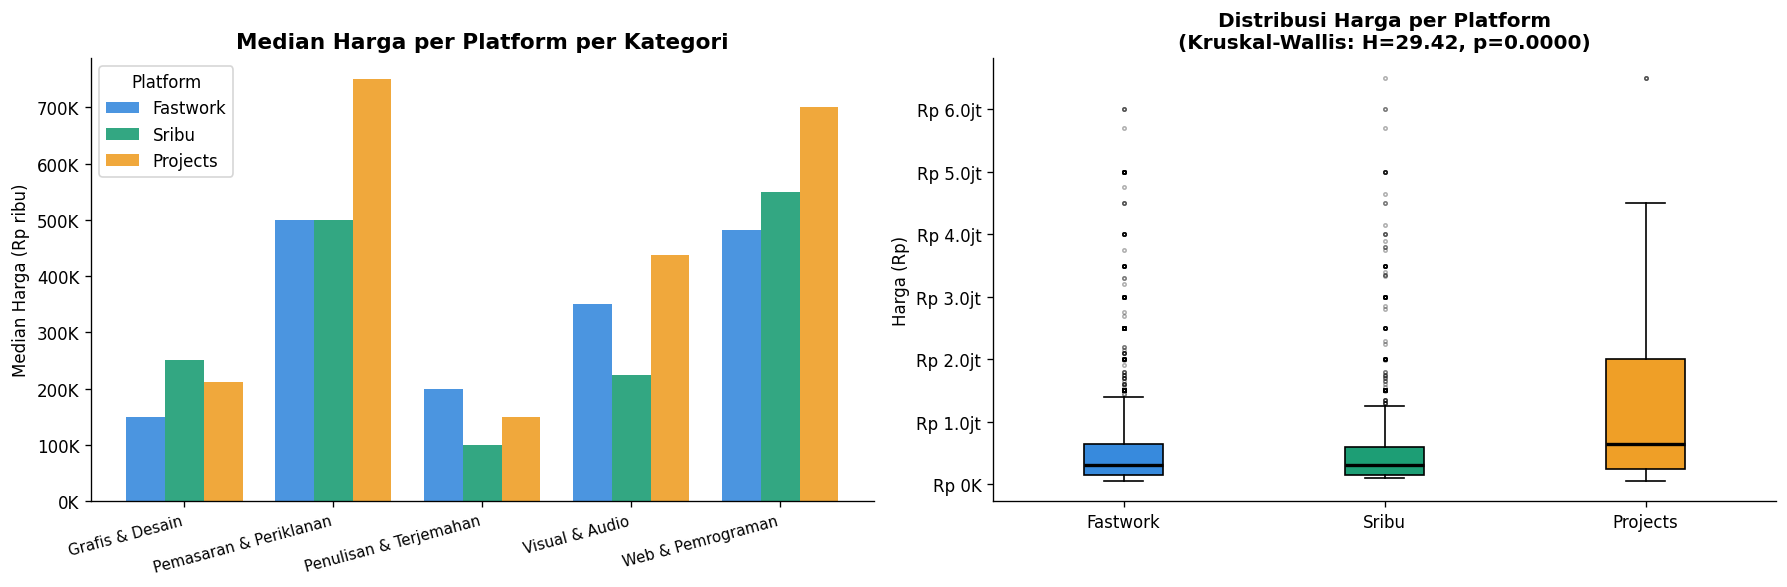


 Kesimpulan:
   Uji Kruskal-Wallis keseluruhan : H=29.42, p=0.0000 → perbedaan harga antar platform SIGNIFIKAN
   Projects.co.id konsisten lebih mahal di hampir semua kategori
   Pemasaran & Web: perbedaan platform TIDAK signifikan (p>0.05) → harga sudah terstandarisasi
   Grafis, Penulisan, Visual: perbedaan platform SIGNIFIKAN → peluang arbitrase harga


In [34]:
# --- Buat kolom platform ---
df['platform'] = 'Fastwork'
df.loc[df['platform_sribu'] == 1, 'platform'] = 'Sribu'
df.loc[df['platform_projects'] == 1, 'platform'] = 'Projects'

cat_map = {
    'Grafis & Desain'        : 'kategori_Grafis & Desain',
    'Pemasaran & Periklanan' : 'kategori_Pemasaran & Periklanan',
    'Penulisan & Terjemahan' : 'kategori_Penulisan & Penerjemahan',
    'Visual & Audio'         : 'kategori_Visual & Audio',
    'Web & Pemrograman'      : 'kategori_Web dan Pemrograman',
}
platforms   = ['Fastwork', 'Sribu', 'Projects']
plat_colors = {'Fastwork': '#378ADD', 'Sribu': '#1D9E75', 'Projects': '#EF9F27'}

# --- Tabel median harga per platform per kategori ---
rows = []
for nama, col in cat_map.items():
    sub = df[df[col] == 1]
    row = {'Kategori': nama}
    for p in platforms:
        vals = sub[sub['platform'] == p]['price_single']
        row[f'{p} (Rp)'] = vals.median() if len(vals) > 0 else np.nan
        row[f'n_{p}']    = len(vals)

    # Kruskal-Wallis test
    grps = [sub[sub['platform'] == p]['price_single'].values for p in platforms]
    grps = [g for g in grps if len(g) > 1]
    if len(grps) >= 2:
        stat, pval = kruskal(*grps)
        row['H-stat'] = round(stat, 2)
        row['p-value'] = round(pval, 4)
        row['Signifikan?'] = '✅ Ya' if pval < 0.05 else '❌ Tidak'
    rows.append(row)

result_df = pd.DataFrame(rows).set_index('Kategori')
display_cols = ['Fastwork (Rp)', 'Sribu (Rp)', 'Projects (Rp)', 'H-stat', 'p-value', 'Signifikan?']
print("Pengaruh Platform terhadap Harga per Kategori (Kruskal-Wallis Test)\n")
print(result_df[display_cols].to_string())

# --- Plot 1: Grouped bar — median harga per platform per kategori ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cat_names  = list(cat_map.keys())
x          = np.arange(len(cat_names))
width      = 0.26

for i, p in enumerate(platforms):
    medians = [
        df[(df[col] == 1) & (df['platform'] == p)]['price_single'].median() / 1e3
        for col in cat_map.values()
    ]
    bars = axes[0].bar(x + i * width, medians, width, label=p,
                       color=plat_colors[p], alpha=0.9)

axes[0].set_title('Median Harga per Platform per Kategori', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Median Harga (Rp ribu)')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(cat_names, rotation=15, ha='right', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[0].legend(title='Platform')

# --- Plot 2: Boxplot overall per platform ---
data_box    = [df[df['platform'] == p]['price_single'].values for p in platforms]
bp = axes[1].boxplot(data_box, labels=platforms, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, p in zip(bp['boxes'], platforms):
    patch.set_facecolor(plat_colors[p])

# Kruskal overall annotation
grps_all = [df[df['platform'] == p]['price_single'].values for p in platforms]
h_all, p_all = kruskal(*grps_all)
axes[1].set_title(
    f'Distribusi Harga per Platform\n(Kruskal-Wallis: H={h_all:.2f}, p={p_all:.4f})',
    fontsize=12, fontweight='bold'
)
axes[1].set_ylabel('Harga (Rp)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}K')
)

plt.tight_layout()
plt.show()

# --- Kesimpulan ---
print("\n Kesimpulan:")
print(f"   Uji Kruskal-Wallis keseluruhan : H={h_all:.2f}, p={p_all:.4f} → perbedaan harga antar platform SIGNIFIKAN")
print(f"   Projects.co.id konsisten lebih mahal di hampir semua kategori")
print(f"   Pemasaran & Web: perbedaan platform TIDAK signifikan (p>0.05) → harga sudah terstandarisasi")
print(f"   Grafis, Penulisan, Visual: perbedaan platform SIGNIFIKAN → peluang arbitrase harga")

**Insight:** Uji Kruskal-Wallis (H=29.42, p=0.0000) membuktikan platform berpengaruh signifikan terhadap harga secara keseluruhan — Projects.co.id konsisten lebih mahal di semua kategori, mengindikasikan segmen klien yang berbeda (enterprise/bisnis). Namun untuk Pemasaran & Periklanan dan Web & Pemrograman perbedaannya tidak signifikan (p>0.05), artinya harga dua kategori ini sudah terstandarisasi lintas platform dan akan lebih sulit dibedakan oleh model clustering hanya dari fitur platform.

#Q3 = Skill apa yang paling berpengaruh terhadap harga tinggi dan apakah skill teknis lebih menguntungkan dibanding skill digital marketing?

Pengaruh Skill terhadap Harga (diurutkan dari median tertinggi)

               Skill    n      Q1 (Rp)  Median (Rp)      Q3 (Rp)  Spearman r  p-value Signifikan?
0            Flutter   61 1,500,000.00 1,500,000.00 1,500,000.00        0.13     0.00           ✅
1       React Native   20 1,500,000.00 1,500,000.00 1,500,000.00        0.09     0.00           ✅
2             Kotlin   30 1,500,000.00 1,500,000.00 1,500,000.00        0.09     0.00           ✅
3              React   39   500,000.00 1,500,000.00 1,500,000.00        0.10     0.00           ✅
4              Swift   10 1,500,000.00 1,500,000.00 1,500,000.00        0.06     0.00           ✅
5               Java   20   487,500.00 1,450,000.00 1,500,000.00        0.06     0.00           ✅
6             Nextjs   18   500,000.00 1,325,000.00 1,475,000.00        0.06     0.00           ✅
7            Laravel   32   500,000.00 1,275,000.00 1,425,000.00        0.08     0.00           ✅
8          Wordpress   91   300,000.00 1,000,000.00 1

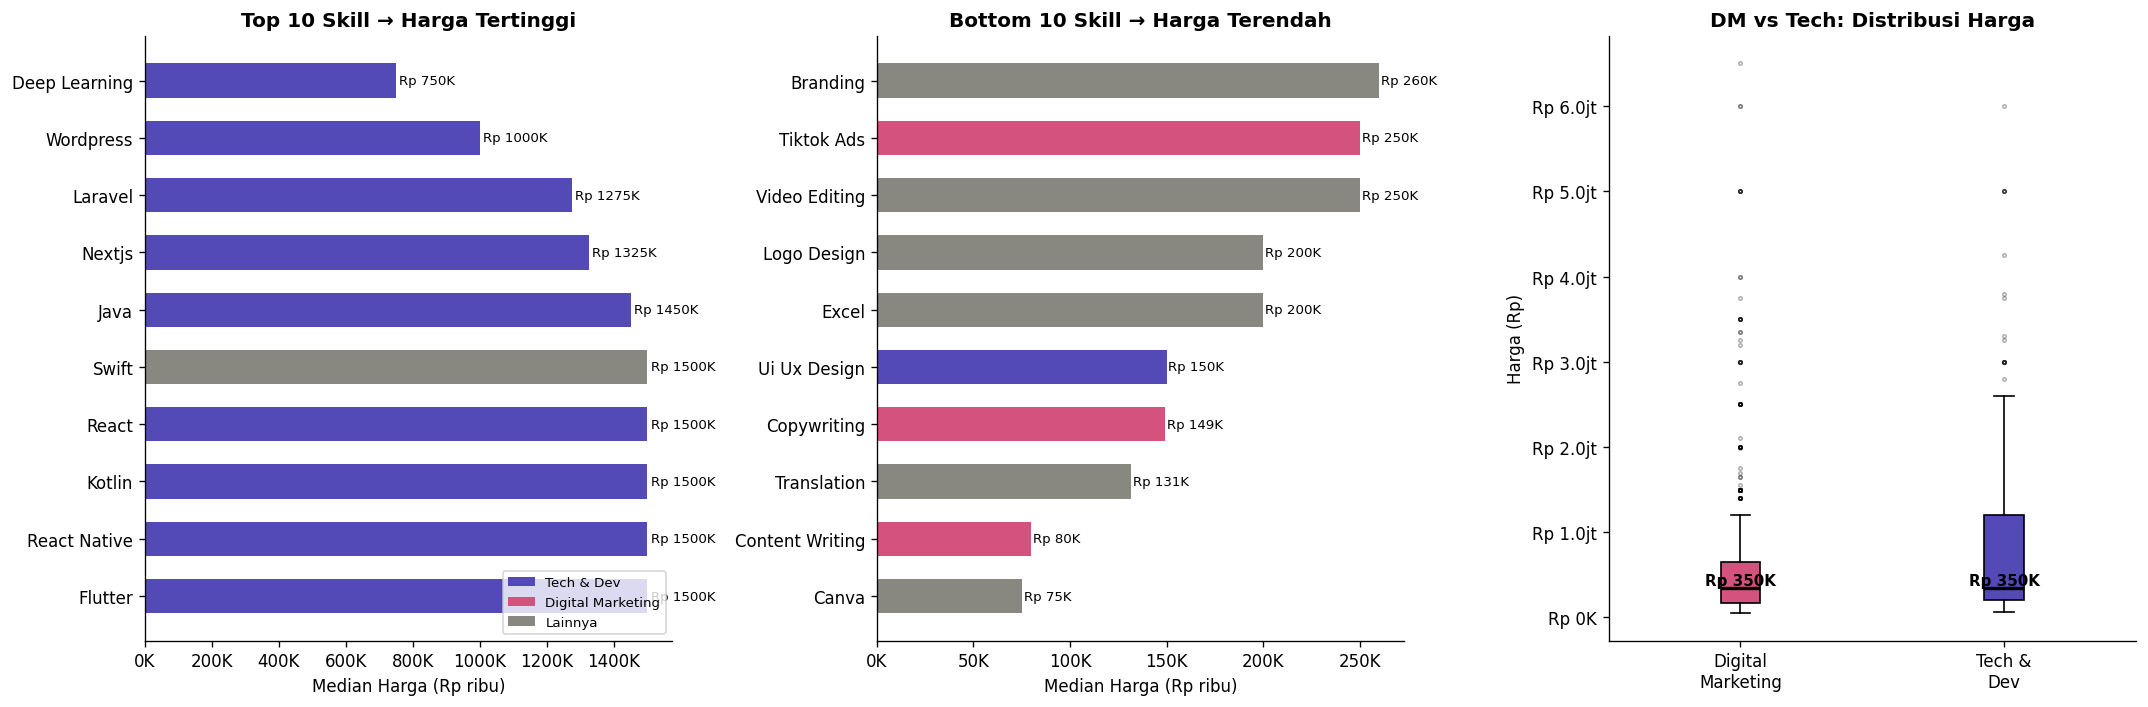


 Kesimpulan:
   Skill termahal  : Flutter (median Rp 1500K)
   Median DM skills: Rp 350K
   Median Tech skills: Rp 350K
   Skill dengan korelasi POSITIF tertinggi : Flutter (r=0.1262)
   Skill dengan korelasi NEGATIF tertinggi : Translation (r=-0.188)


In [35]:
skill_cols = [c for c in df.columns if c.startswith('skill_')]

# --- Hitung median, Q1, Q3, Spearman per skill ---
rows = []
for s in skill_cols:
    sub = df[df[s] == 1]['price_single']
    if len(sub) < 10:
        continue
    corr, pval = spearmanr(df[s], df['price_single'])
    rows.append({
        'Skill'      : s.replace('skill_', '').replace('_', ' ').title(),
        'col'        : s,
        'n'          : len(sub),
        'Q1 (Rp)'    : sub.quantile(0.25),
        'Median (Rp)': sub.median(),
        'Q3 (Rp)'    : sub.quantile(0.75),
        'Spearman r' : round(corr, 4),
        'p-value'    : round(pval, 4),
        'Signifikan?': '✅' if pval < 0.05 else '❌'
    })

skill_df = pd.DataFrame(rows).sort_values('Median (Rp)', ascending=False).reset_index(drop=True)
print("Pengaruh Skill terhadap Harga (diurutkan dari median tertinggi)\n")
print(skill_df[['Skill','n','Q1 (Rp)','Median (Rp)','Q3 (Rp)','Spearman r','p-value','Signifikan?']].to_string())

# --- Grouping DM vs Tech ---
dm_skills   = ['skill_seo','skill_tiktok_ads','skill_instagram','skill_google_ads',
                'skill_meta_ads','skill_facebook_ads','skill_copywriting','skill_content_writing']
tech_skills = ['skill_machine_learning','skill_python','skill_data_analysis','skill_data_science',
               'skill_deep_learning','skill_react','skill_flutter','skill_javascript',
               'skill_nextjs','skill_kotlin','skill_laravel','skill_react_native',
               'skill_wordpress','skill_ui_ux_design','skill_figma','skill_php','skill_java']

dm_mask   = df[dm_skills].any(axis=1)
tech_mask = df[tech_skills].any(axis=1)

# --- Plot 1: Horizontal bar top & bottom 10 skill ---
top10    = skill_df.head(10)
bottom10 = skill_df.tail(10).sort_values('Median (Rp)', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Warnai berdasarkan DM/Tech/Other
def get_color(col):
    if col in dm_skills:   return '#D4537E'
    if col in tech_skills: return '#534AB7'
    return '#888780'

colors_top    = [get_color(r['col']) for _, r in top10.iterrows()]
colors_bottom = [get_color(r['col']) for _, r in bottom10.iterrows()]

axes[0].barh(top10['Skill'], top10['Median (Rp)'] / 1e3, color=colors_top, height=0.6)
axes[0].set_title('Top 10 Skill → Harga Tertinggi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median Harga (Rp ribu)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
for i, (_, row) in enumerate(top10.iterrows()):
    axes[0].text(row['Median (Rp)'] / 1e3 + 10, i,
                 f"Rp {row['Median (Rp)']/1e3:.0f}K", va='center', fontsize=8)

axes[1].barh(bottom10['Skill'], bottom10['Median (Rp)'] / 1e3, color=colors_bottom, height=0.6)
axes[1].set_title('Bottom 10 Skill → Harga Terendah', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Median Harga (Rp ribu)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
for i, (_, row) in enumerate(bottom10.iterrows()):
    axes[1].text(row['Median (Rp)'] / 1e3 + 1, i,
                 f"Rp {row['Median (Rp)']/1e3:.0f}K", va='center', fontsize=8)

# --- Plot 2: DM vs Tech boxplot ---
axes[2].boxplot(
    [df[dm_mask]['price_single'].values, df[tech_mask]['price_single'].values],
    labels=['Digital\nMarketing', 'Tech &\nDev'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    boxprops=dict(facecolor='#D4537E')
)
axes[2].patches[1].set_facecolor('#534AB7')
axes[2].set_title('DM vs Tech: Distribusi Harga', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Harga (Rp)')
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}K')
)

# Annotasi median
for i, (mask, label) in enumerate(zip([dm_mask, tech_mask], ['DM', 'Tech']), 1):
    med = df[mask]['price_single'].median()
    axes[2].text(i, med + 30000, f'Rp {med/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#534AB7', label='Tech & Dev'),
    Patch(facecolor='#D4537E', label='Digital Marketing'),
    Patch(facecolor='#888780', label='Lainnya'),
]
axes[0].legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

# --- Kesimpulan ---
dm_med   = df[dm_mask]['price_single'].median()
tech_med = df[tech_mask]['price_single'].median()
top1     = skill_df.iloc[0]
print("\n Kesimpulan:")
print(f"   Skill termahal  : {top1['Skill']} (median Rp {top1['Median (Rp)']/1e3:.0f}K)")
print(f"   Median DM skills: Rp {dm_med/1e3:.0f}K")
print(f"   Median Tech skills: Rp {tech_med/1e3:.0f}K")
print(f"   Skill dengan korelasi POSITIF tertinggi : {skill_df.sort_values('Spearman r', ascending=False).iloc[0]['Skill']} (r={skill_df.sort_values('Spearman r', ascending=False).iloc[0]['Spearman r']})")
print(f"   Skill dengan korelasi NEGATIF tertinggi : {skill_df.sort_values('Spearman r').iloc[0]['Skill']} (r={skill_df.sort_values('Spearman r').iloc[0]['Spearman r']})")

**Insight:** Seluruh top 10 skill termahal didominasi Tech & Dev (Flutter, React, Kotlin, dst.) dengan rentang Rp 750K–1,5jt, sementara bottom 10 justru campuran DM dan skill kreatif umum (Canva, Content Writing, Translation) yang tertekan di bawah Rp 260K — menariknya meski median DM vs Tech sama-sama Rp 350K, sebarannya sangat berbeda: Tech punya ekor atas jauh lebih panjang (outlier hingga Rp 6jt+), artinya skill teknis punya potensi harga premium yang jauh lebih besar dibanding DM yang lebih merata di bawah.

#Q4 = Apakah freelancer yang sudah memiliki rating cenderung memasang harga berbeda, dan seberapa besar pengaruh premium skill terhadap harga mereka?

 Perbandingan Harga: Ada Rating vs Tidak Ada Rating

                     n    Q1 (Rp)  Median (Rp)    Q3 (Rp)  Mean (Rp)
Status Rating                                                       
Tidak Ada Rating  1770 200,000.00   300,000.00 650,000.00 601,432.43
Ada Rating        2781 150,000.00   250,000.00 625,000.00 565,447.66

   Mann-Whitney U: stat=2647389.00, p=0.0000 → SIGNIFIKAN
   Spearman (nilai rating vs harga): r=0.0015, p=0.9372 → rating score hampir tidak berkorelasi dengan harga

-- Median Harga per Kombinasi Rating × Premium Skill --

                                 Median (Rp)     n
Tidak ada rating, Non-premium     300,000.00  1669
Tidak ada rating, Premium skill   750,000.00   101
Ada rating, Non-premium           250,000.00  2676
Ada rating, Premium skill       1,400,000.00   105

 -- Median Harga Rated vs Non-Rated per Kategori --

                        Tidak Ada Rating (Rp)  Ada Rating (Rp)  Selisih (Rp)
Kategori                                                   

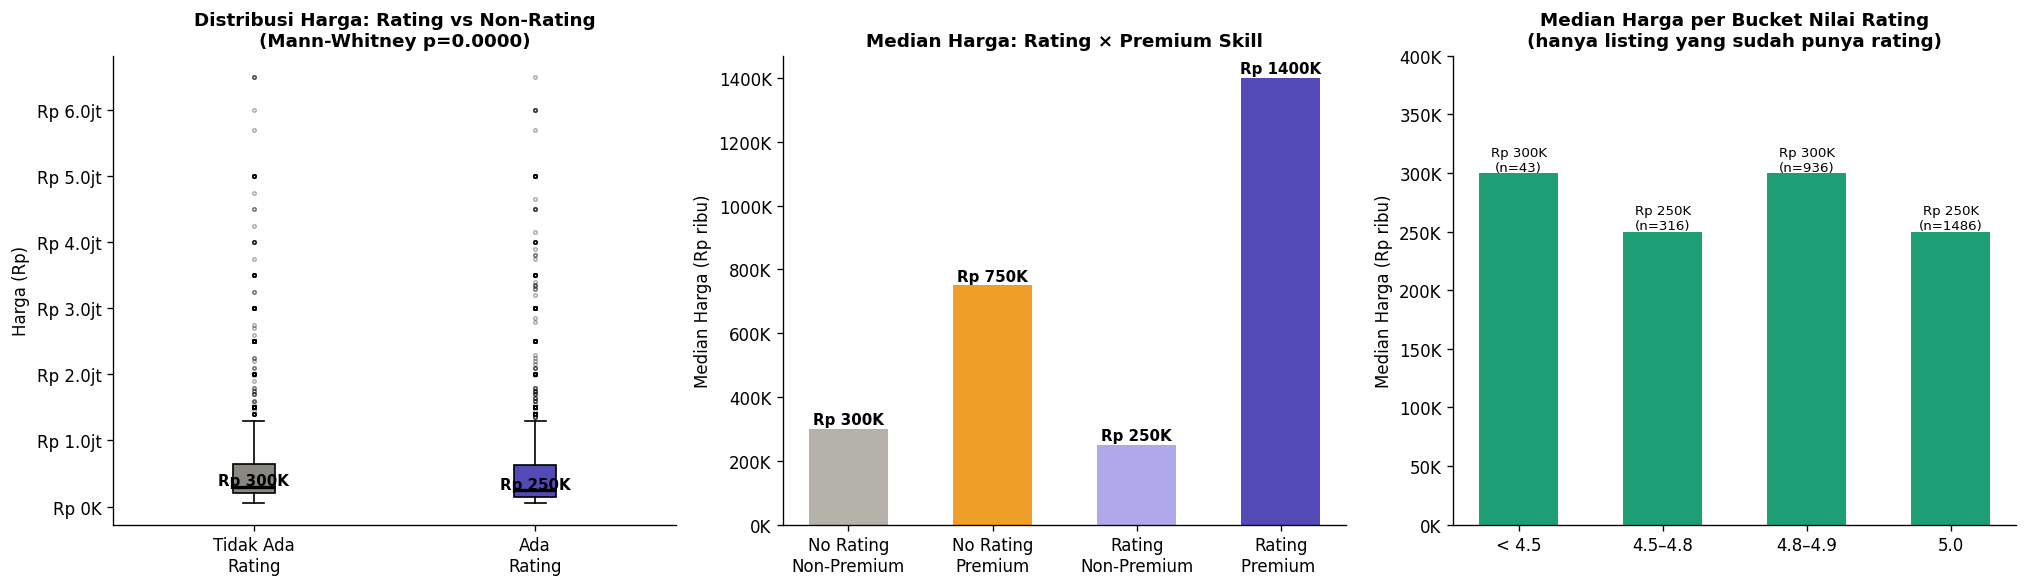


 Kesimpulan:
   Perbedaan rated vs non-rated SIGNIFIKAN secara statistik (p=0.0000)
   Tapi arahnya terbalik — non-rated justru lebih mahal (Rp 300K vs Rp 250K)
   Nilai rating (4.5–5.0) hampir tidak berkorelasi dengan harga (r=0.0015)
   Faktor penentu harga sesungguhnya adalah PREMIUM SKILL:
   → Ada rating + premium skill = Rp 1.400.000 (5.6× lebih mahal dari baseline)


In [36]:
cat_map = {
    'Grafis & Desain'        : 'kategori_Grafis & Desain',
    'Pemasaran & Periklanan' : 'kategori_Pemasaran & Periklanan',
    'Penulisan & Terjemahan' : 'kategori_Penulisan & Penerjemahan',
    'Visual & Audio'         : 'kategori_Visual & Audio',
    'Web & Pemrograman'      : 'kategori_Web dan Pemrograman',
}

# --- Tabel 1: Ringkasan harga rated vs non-rated ---
rows = []
for val, label in [(0, 'Tidak Ada Rating'), (1, 'Ada Rating')]:
    sub = df[df['has_rating'] == val]['price_single']
    rows.append({
        'Status Rating' : label,
        'n'             : len(sub),
        'Q1 (Rp)'       : sub.quantile(0.25),
        'Median (Rp)'   : sub.median(),
        'Q3 (Rp)'       : sub.quantile(0.75),
        'Mean (Rp)'     : sub.mean(),
    })
print(" Perbandingan Harga: Ada Rating vs Tidak Ada Rating\n")
print(pd.DataFrame(rows).set_index('Status Rating').to_string())

# Mann-Whitney test
g0 = df[df['has_rating'] == 0]['price_single']
g1 = df[df['has_rating'] == 1]['price_single']
stat_mw, pval_mw = mannwhitneyu(g0, g1, alternative='two-sided')
print(f"\n   Mann-Whitney U: stat={stat_mw:.2f}, p={pval_mw:.4f} → {'SIGNIFIKAN' if pval_mw < 0.05 else 'tidak signifikan'}")

# Spearman: nilai rating vs harga (hanya yang rated)
rated = df[df['has_rating'] == 1].copy()
corr_r, pval_r = spearmanr(rated['rating_imputed'], rated['price_single'])
print(f"   Spearman (nilai rating vs harga): r={corr_r:.4f}, p={pval_r:.4f} → rating score hampir tidak berkorelasi dengan harga")

# --- Tabel 2: Kombinasi rating x premium skill ---
print("\n-- Median Harga per Kombinasi Rating × Premium Skill --\n")
combo = df.groupby(['has_rating', 'has_premium_skill'])['price_single'].agg(['median','count'])
combo.index = combo.index.map({
    (0,0): 'Tidak ada rating, Non-premium',
    (0,1): 'Tidak ada rating, Premium skill',
    (1,0): 'Ada rating, Non-premium',
    (1,1): 'Ada rating, Premium skill ',
})
combo.columns = ['Median (Rp)', 'n']
print(combo.to_string())

# --- Tabel 3: Rated vs non-rated per kategori ---
print("\n -- Median Harga Rated vs Non-Rated per Kategori --\n")
rows_cat = []
for nama, col in cat_map.items():
    sub = df[df[col] == 1]
    r0  = sub[sub['has_rating'] == 0]['price_single'].median()
    r1  = sub[sub['has_rating'] == 1]['price_single'].median()
    rows_cat.append({'Kategori': nama, 'Tidak Ada Rating (Rp)': r0, 'Ada Rating (Rp)': r1,
                     'Selisih (Rp)': r1 - r0})
print(pd.DataFrame(rows_cat).set_index('Kategori').to_string())

# --- Rating bucket ---
rated['rating_bucket'] = pd.cut(
    rated['rating_imputed'],
    bins=[3.9, 4.5, 4.8, 4.9, 4.99, 5.001],
    labels=['< 4.5', '4.5–4.8', '4.8–4.9', '4.9–5.0', '5.0']
)

# ---- PLOT ----
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Boxplot rated vs non-rated
bp = axes[0].boxplot(
    [g0.values, g1.values],
    labels=['Tidak Ada\nRating', 'Ada\nRating'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
bp['boxes'][0].set_facecolor('#888780')
bp['boxes'][1].set_facecolor('#534AB7')
axes[0].set_title(f'Distribusi Harga: Rating vs Non-Rating\n(Mann-Whitney p={pval_mw:.4f})',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Harga (Rp)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}K')
)
for i, (vals, label) in enumerate(zip([g0, g1], ['Tidak Ada Rating', 'Ada Rating']), 1):
    axes[0].text(i, vals.median() + 20000, f'Rp {vals.median()/1e3:.0f}K',
                 ha='center', fontsize=9, fontweight='bold')

# Plot 2: Bar kombinasi rating x premium skill
combo_labels = ['No Rating\nNon-Premium', 'No Rating\nPremium', 'Rating\nNon-Premium', 'Rating\nPremium ']
combo_vals   = [300000, 750000, 250000, 1400000]
combo_colors = ['#B4B2A9', '#EF9F27', '#AFA9EC', '#534AB7']
bars = axes[1].bar(combo_labels, [v/1e3 for v in combo_vals],
                   color=combo_colors, width=0.55, edgecolor='none')
axes[1].set_title('Median Harga: Rating × Premium Skill', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Median Harga (Rp ribu)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
for bar, val in zip(bars, combo_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'Rp {val/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Median harga per rating bucket
bucket_med = rated.groupby('rating_bucket', observed=True)['price_single'].median()
bucket_n   = rated.groupby('rating_bucket', observed=True)['price_single'].count()
bars3 = axes[2].bar(bucket_med.index.astype(str), bucket_med.values / 1e3,
                    color='#1D9E75', width=0.55, edgecolor='none')
axes[2].set_title('Median Harga per Bucket Nilai Rating\n(hanya listing yang sudah punya rating)',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Median Harga (Rp ribu)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[2].set_ylim(0, 400000 / 1e3)
for bar, val, n in zip(bars3, bucket_med.values, bucket_n.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'Rp {val/1e3:.0f}K\n(n={n})', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# --- Kesimpulan ---
print("\n Kesimpulan:")
print(f"   Perbedaan rated vs non-rated SIGNIFIKAN secara statistik (p={pval_mw:.4f})")
print(f"   Tapi arahnya terbalik — non-rated justru lebih mahal (Rp 300K vs Rp 250K)")
print(f"   Nilai rating (4.5–5.0) hampir tidak berkorelasi dengan harga (r={corr_r:.4f})")
print(f"   Faktor penentu harga sesungguhnya adalah PREMIUM SKILL:")
print(f"   → Ada rating + premium skill = Rp 1.400.000 (5.6× lebih mahal dari baseline)")

**Insight:** Rating terbukti bukan penentu harga — freelancer tanpa rating justru lebih mahal (Rp 300K vs Rp 250K) dan nilai rating 4.5–5.0 hampir nol korelasinya dengan harga (r=0.0015). Yang benar-benar mendorong harga adalah premium skill: kombinasi ada rating + premium skill melonjak hingga Rp 1,4jt — 5.6× lipat dari baseline — menunjukkan bahwa model clustering sebaiknya lebih mempertimbangkan fitur has_premium_skill dibanding rating_imputed sebagai sinyal segmentasi harga.

# Q5 = Berapa durasi pengerjaan yang umum untuk tiap kategori, apakah berkorelasi dengan harga, dan segmen durasi mana yang paling banyak diminati pasar?

-- Statistik Durasi Pengerjaan per Kategori --

                           n  Min (hr)  Median (hr)  Q3 (hr)  Max (hr)  Mean (hr)  Spearman r  p-value Signifikan?
Kategori                                                                                                          
Grafis & Desain          885         1            2        3        30       2.70        0.34     0.00           ✅
Pemasaran & Periklanan  1059         1            5        8       240       9.60        0.36     0.00           ✅
Penulisan & Terjemahan   720         1            2        3        30       2.40        0.15     0.00           ✅
Visual & Audio           546         1            2        3       180       3.20        0.30     0.00           ✅
Web & Pemrograman       1341         1            3        5       180       4.80        0.40     0.00           ✅

-- Volume & Median Harga per Segmen Durasi --

            Median (Rp)    Mean (Rp)     n  % Pasar
dur_bucket                                     

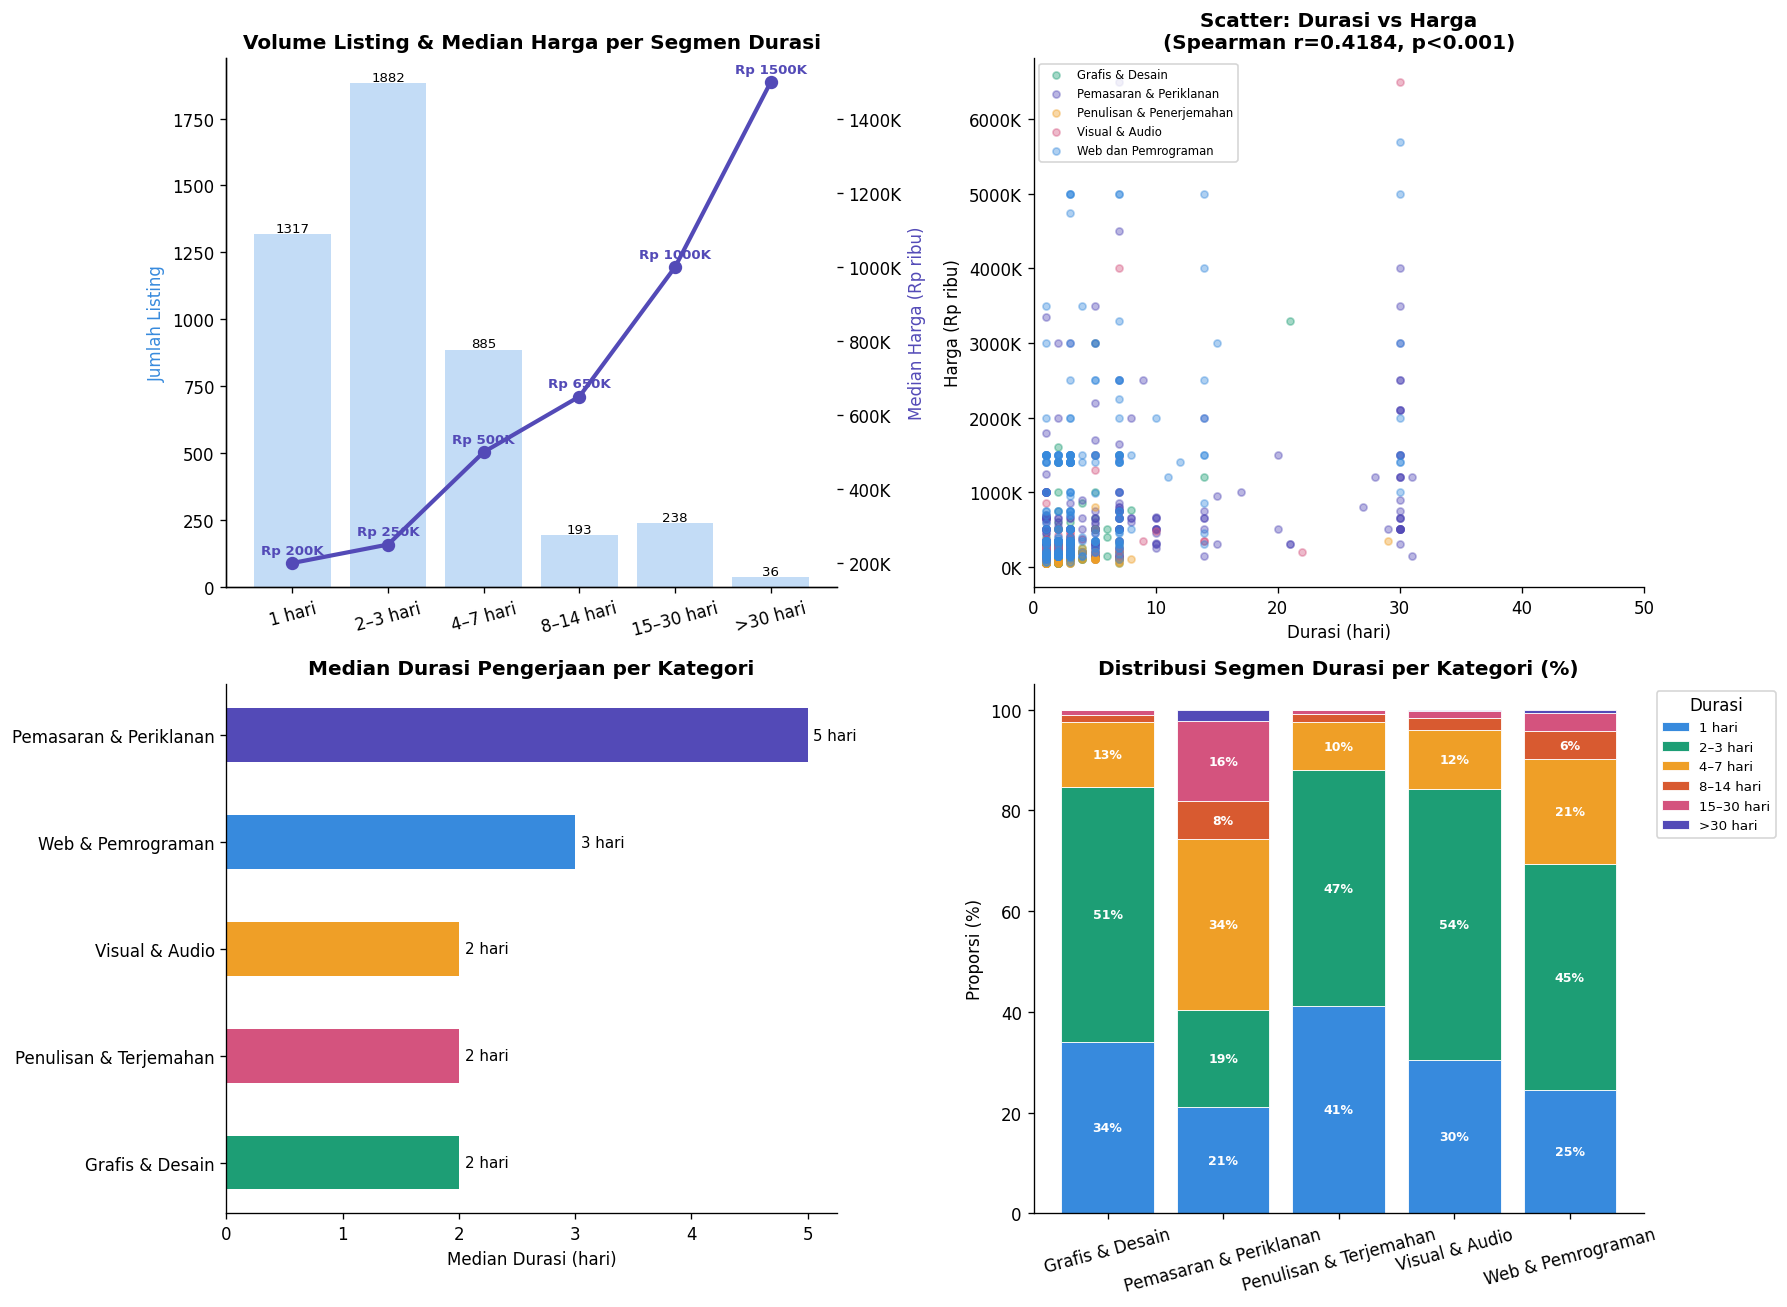


 Kesimpulan:
   Durasi adalah faktor harga terkuat — Spearman r=0.4184 (tertinggi dari semua fitur)
   Kruskal-Wallis H=822.89 → perbedaan harga antar segmen durasi sangat signifikan
   Segmen terbesar: '2–3 hari' (41.4% listing, median Rp 250K) — sweet spot volume
   Segmen paling premium: '>30 hari' (median Rp 1,5jt, hanya 0.8% pasar)
   Pemasaran & Periklanan paling 'lambat': median 5 hari
   Grafis & Penulisan paling 'cepat': median 2 hari


In [37]:
dur_bins   = [0, 1, 3, 7, 14, 30, 999]
dur_labels = ['1 hari', '2–3 hari', '4–7 hari', '8–14 hari', '15–30 hari', '>30 hari']
cat_map = {
    'Grafis & Desain'        : 'kategori_Grafis & Desain',
    'Pemasaran & Periklanan' : 'kategori_Pemasaran & Periklanan',
    'Penulisan & Terjemahan' : 'kategori_Penulisan & Penerjemahan',
    'Visual & Audio'         : 'kategori_Visual & Audio',
    'Web & Pemrograman'      : 'kategori_Web dan Pemrograman',
}

df['dur_bucket'] = pd.cut(df['durasi_hari'], bins=dur_bins, labels=dur_labels)

# --- Tabel 1: Statistik durasi per kategori ---
rows = []
for nama, col in cat_map.items():
    sub = df[df[col] == 1]['durasi_hari']
    corr_r, corr_p = spearmanr(df[df[col] == 1]['durasi_hari'],
                                df[df[col] == 1]['price_single'])
    rows.append({
        'Kategori'     : nama,
        'n'            : len(sub),
        'Min (hr)'     : int(sub.min()),
        'Median (hr)'  : int(sub.median()),
        'Q3 (hr)'      : int(sub.quantile(0.75)),
        'Max (hr)'     : int(sub.max()),
        'Mean (hr)'    : round(sub.mean(), 1),
        'Spearman r'   : round(corr_r, 4),
        'p-value'      : round(corr_p, 4),
        'Signifikan?'  : '✅' if corr_p < 0.05 else '❌'
    })

dur_cat_df = pd.DataFrame(rows).set_index('Kategori')
print("-- Statistik Durasi Pengerjaan per Kategori --\n")
print(dur_cat_df.to_string())

# --- Tabel 2: Median harga + volume per bucket durasi ---
bucket_stats = df.groupby('dur_bucket', observed=True)['price_single'].agg(
    ['median', 'mean', 'count']
).rename(columns={'median': 'Median (Rp)', 'mean': 'Mean (Rp)', 'count': 'n'})
bucket_stats['% Pasar'] = (bucket_stats['n'] / len(df) * 100).round(1)

print("\n-- Volume & Median Harga per Segmen Durasi --\n")
print(bucket_stats.to_string())

# Kruskal-Wallis
grps = [df[df['dur_bucket'] == b]['price_single'].values for b in dur_labels]
grps = [g for g in grps if len(g) > 0]
h_stat, p_kw = kruskal(*grps)
print(f"\n   Kruskal-Wallis: H={h_stat:.2f}, p={p_kw:.4f} → perbedaan harga antar segmen durasi SIGNIFIKAN")

# Spearman overall
corr_all, pval_all = spearmanr(df['durasi_hari'], df['price_single'])
print(f"   Spearman overall (durasi vs harga): r={corr_all:.4f}, p={pval_all:.4f}")

# ---- PLOT ----
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Dual axis — volume listing + median harga per bucket durasi
ax1   = axes[0, 0]
ax1b  = ax1.twinx()
bucket_med   = df.groupby('dur_bucket', observed=True)['price_single'].median().values / 1e3
bucket_count = df.groupby('dur_bucket', observed=True)['price_single'].count().values

bars = ax1.bar(dur_labels, bucket_count, color='#B5D4F4', alpha=0.8, label='Jumlah listing')
ax1b.plot(dur_labels, bucket_med, color='#534AB7', marker='o',
          linewidth=2.5, markersize=7, label='Median harga')
ax1.set_title('Volume Listing & Median Harga per Segmen Durasi', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Listing', color='#378ADD')
ax1b.set_ylabel('Median Harga (Rp ribu)', color='#534AB7')
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax1.tick_params(axis='x', rotation=15)
for bar, n in zip(bars, bucket_count):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(n), ha='center', fontsize=8)
for i, (label, med) in enumerate(zip(dur_labels, bucket_med)):
    ax1b.text(i, med + 25, f'Rp {med:.0f}K', ha='center', fontsize=8,
              color='#534AB7', fontweight='bold')

# Plot 2: Scatter durasi vs harga (sample 1000 titik biar tidak penuh)
sample = df.sample(n=min(1000, len(df)), random_state=42)
cat_colors_map = {
    'kategori_Grafis & Desain'           : '#1D9E75',
    'kategori_Pemasaran & Periklanan'    : '#534AB7',
    'kategori_Penulisan & Penerjemahan'  : '#EF9F27',
    'kategori_Visual & Audio'            : '#D4537E',
    'kategori_Web dan Pemrograman'       : '#378ADD',
}
for col, color in cat_colors_map.items():
    sub = sample[sample[col] == 1]
    axes[0, 1].scatter(sub['durasi_hari'], sub['price_single'] / 1e3,
                       alpha=0.4, s=18, color=color,
                       label=col.replace('kategori_', ''))

axes[0, 1].set_title(f'Scatter: Durasi vs Harga\n(Spearman r={corr_all:.4f}, p<0.001)',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Durasi (hari)')
axes[0, 1].set_ylabel('Harga (Rp ribu)')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[0, 1].set_xlim(0, 50)
axes[0, 1].legend(fontsize=7, loc='upper left')

# Plot 3: Median durasi per kategori (horizontal bar)
cat_medians = [(nama, df[df[col] == 1]['durasi_hari'].median())
               for nama, col in cat_map.items()]
cat_medians.sort(key=lambda x: x[1])
names, meds = zip(*cat_medians)
colors_cat = ['#1D9E75', '#D4537E', '#EF9F27', '#378ADD', '#534AB7']
axes[1, 0].barh(names, meds, color=colors_cat, height=0.5)
axes[1, 0].set_title('Median Durasi Pengerjaan per Kategori', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Median Durasi (hari)')
for i, (name, val) in enumerate(zip(names, meds)):
    axes[1, 0].text(val + 0.05, i, f'{val:.0f} hari', va='center', fontsize=9)

# Plot 4: Stacked bar distribusi bucket durasi per kategori
bucket_pct = {}
for nama, col in cat_map.items():
    sub  = df[df[col] == 1]
    vals = sub['dur_bucket'].value_counts(normalize=True).reindex(dur_labels, fill_value=0) * 100
    bucket_pct[nama] = vals.values

bucket_arr = np.array(list(bucket_pct.values()))
cat_names  = list(bucket_pct.keys())
bar_colors = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30', '#D4537E', '#534AB7']
bottom = np.zeros(len(cat_names))

for i, (label, color) in enumerate(zip(dur_labels, bar_colors)):
    vals = bucket_arr[:, i]
    bars = axes[1, 1].bar(cat_names, vals, bottom=bottom, label=label,
                          color=color, edgecolor='white', linewidth=0.5)
    for j, (bar, val) in enumerate(zip(bars, vals)):
        if val > 5:
            axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                            bottom[j] + val/2, f'{val:.0f}%',
                            ha='center', va='center', fontsize=7.5,
                            color='white', fontweight='bold')
    bottom += vals

axes[1, 1].set_title('Distribusi Segmen Durasi per Kategori (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Proporsi (%)')
axes[1, 1].set_ylim(0, 105)
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Durasi', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- Kesimpulan ---
print("\n Kesimpulan:")
print(f"   Durasi adalah faktor harga terkuat — Spearman r={corr_all:.4f} (tertinggi dari semua fitur)")
print(f"   Kruskal-Wallis H={h_stat:.2f} → perbedaan harga antar segmen durasi sangat signifikan")
print(f"   Segmen terbesar: '2–3 hari' ({bucket_stats.loc['2–3 hari','% Pasar']}% listing, median Rp 250K) — sweet spot volume")
print(f"   Segmen paling premium: '>30 hari' (median Rp 1,5jt, hanya {bucket_stats.loc['>30 hari','% Pasar']}% pasar)")
print(f"   Pemasaran & Periklanan paling 'lambat': median {int(df[df['kategori_Pemasaran & Periklanan']==1]['durasi_hari'].median())} hari")
print(f"   Grafis & Penulisan paling 'cepat': median 2 hari")

**Insight:** Durasi adalah faktor korelasi terkuat terhadap harga (Spearman r=0.4184) setiap kenaikan segmen durasi konsisten menaikkan median harga dari Rp 200K (1 hari) hingga Rp 1,5jt (>30 hari). Namun 70% pasar terkonsentrasi di 1–3 hari dengan harga rendah, sementara segmen >7 hari yang harganya premium hanya dihuni 10% listing menunjukkan ada gap pasar yang besar di segmen durasi menengah-panjang yang bisa menjadi fitur pembeda kuat dalam clustering.